In [9]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys, os
package_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Outils/swd")
if package_dir not in sys.path:
    sys.path.insert(0, package_dir)
    
from swd import spherical_processing as sp
from swd import geotools as geo
from swd import plots as splots
import swd as swd
import importlib

importlib.reload(swd.plots)
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Import utils_DirViolins
scripts_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Violon/scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
import utils_DirViolins as utils
importlib.reload(utils)
import utils_SH_selection
importlib.reload(utils_SH_selection)
from scipy.spatial.transform import Rotation

from scipy.stats import special_ortho_group   # Haar-uniform random SO(3)
from scipy.linalg import svd as scipy_svd

In [10]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbViol = 6
Dyn = 36

NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']


## Process the Spherical Harmonics Spectra

In [11]:
MAX_ORDER = 15
CmnFileName = f'./../results/CmnO{MAX_ORDER}_Optimization_Results.npz'
data = np.load(CmnFileName, allow_pickle=True)
results_orders = data['orders']
results_lambdas = data['lambdas']
results_freqs = data['freqs']
Cmn_all = data['Cmn_all']
print(f"Loaded detailed optimization results from {CmnFileName}")

Loaded detailed optimization results from ./../results/CmnO15_Optimization_Results.npz


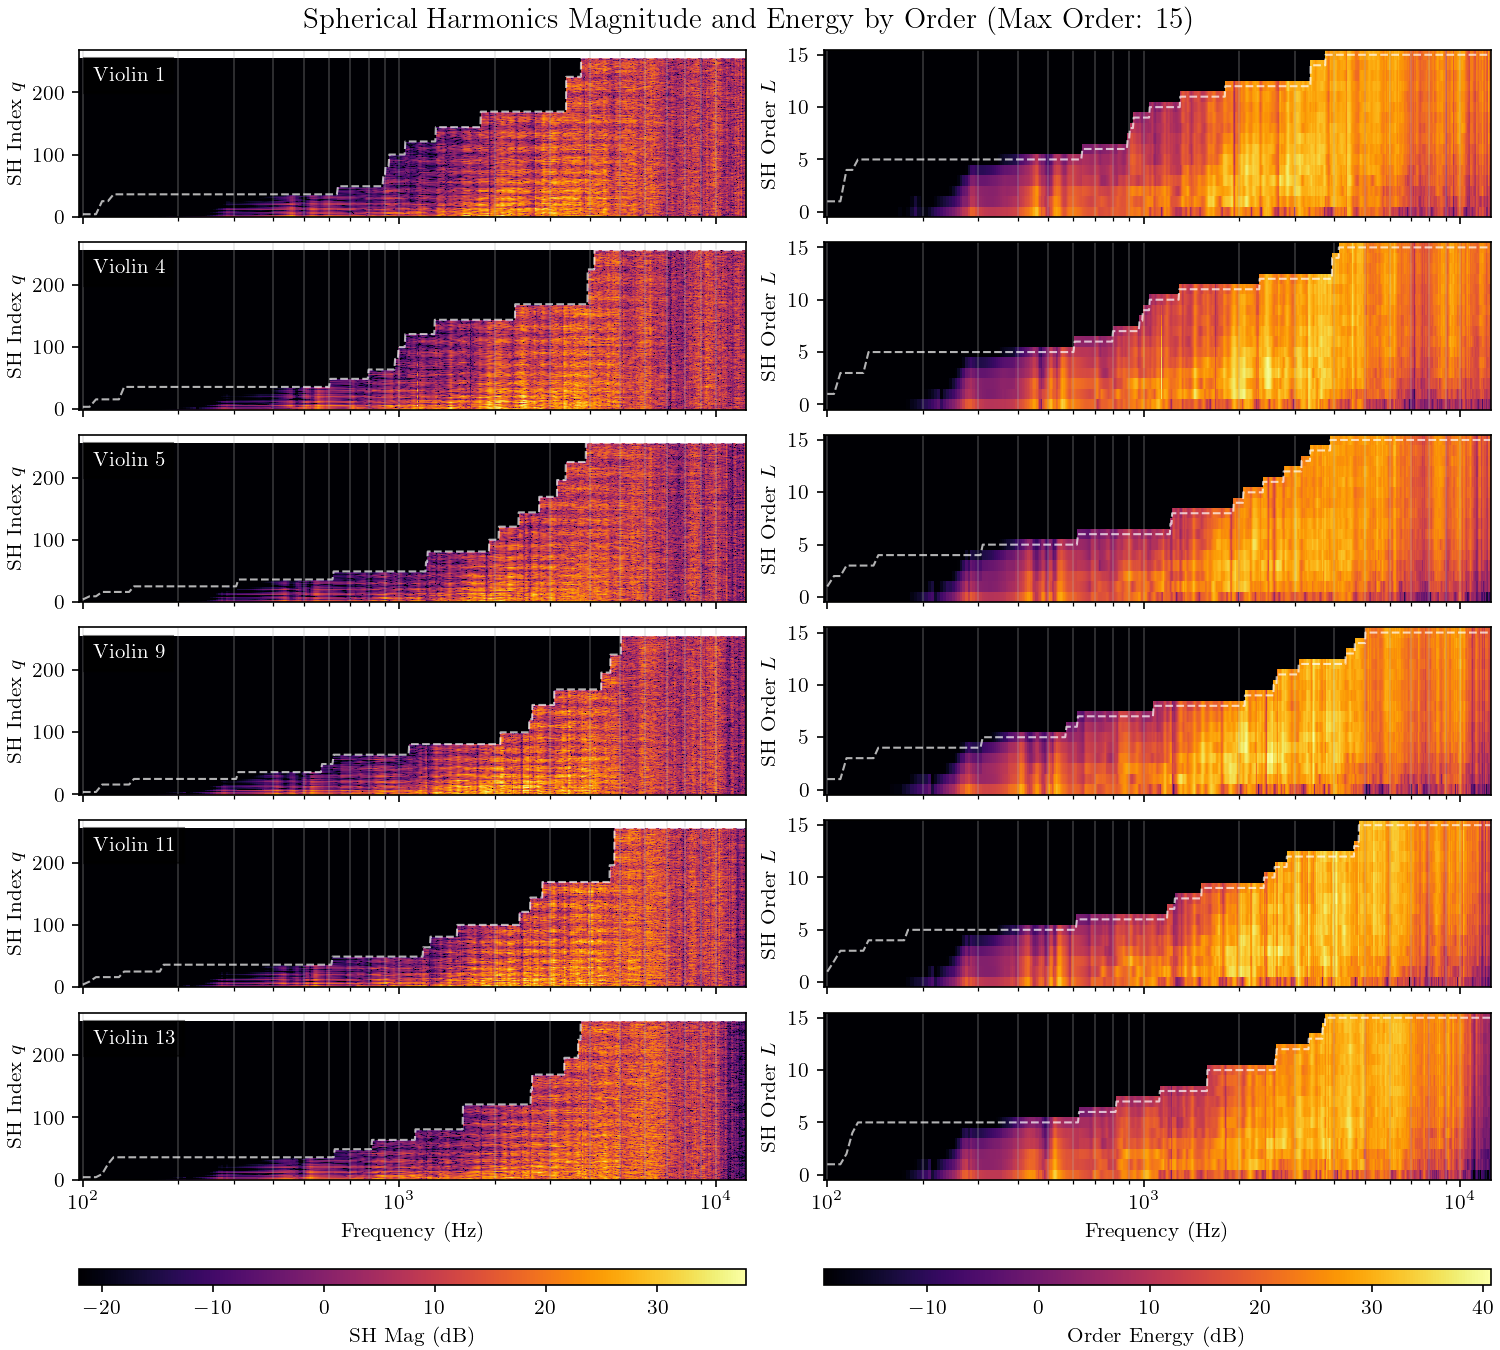

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt

# Check if data is loaded
if 'Cmn_all' not in locals() or 'results_freqs' not in locals():
    print("Please run the data loading cell first.")
else:
    NbViol = Cmn_all.shape[0]
    NbSH_max = Cmn_all.shape[1]
    
    # Calculate Magnitude in dB
    epsilon = 1e-16
    Cmn_mag = np.abs(Cmn_all)
    Cmn_db = 20 * np.log10(Cmn_mag + epsilon)
    
    # Determine color scale (global)
    # Using a percentile or max for robustness
    # global_max = np.percentile(Cmn_db, 99.9) 
    global_max = np.max(Cmn_db)
    vmin = global_max - 60 # 60 dB dynamic range
    vmax = global_max
    
    # Calculate energy by order
    MAX_ORDER_CALC = int(np.sqrt(NbSH_max)) - 1
    Cmn_energy_order = np.zeros((NbViol, MAX_ORDER_CALC + 1, Cmn_all.shape[2]))
    for order in range(MAX_ORDER_CALC + 1):
        start_idx = order**2
        end_idx = (order+1)**2
        Cmn_energy_order[:, order, :] = np.sum(np.abs(Cmn_all[:, start_idx:end_idx, :])**2, axis=1)
    
    Cmn_energy_order_db = 10 * np.log10(Cmn_energy_order + epsilon)
    global_max_energy = np.max(Cmn_energy_order_db)
    vmin_energy = global_max_energy - 60

    fig, axes = plt.subplots(NbViol, 2, figsize=(10, 1.5 * NbViol), sharex=True, constrained_layout=True)
    if NbViol == 1: axes = np.array([axes])
    
    # Axes for pcolormesh
    # f_axis: (Nbf,)
    # sh_axis: (NbSH,)
    f_axis = results_freqs
    sh_axis = np.arange(NbSH_max)
    order_axis = np.arange(MAX_ORDER_CALC + 1)
    
    for v in range(NbViol):
        ax1 = axes[v, 0]
        ax2 = axes[v, 1]
        
        # Plot Heatmap (Coefficients)
        im1 = ax1.pcolormesh(f_axis, sh_axis, Cmn_db[v, :, :], 
                             vmin=vmin, vmax=vmax, cmap='inferno', shading='nearest')
        
        # Plot Heatmap (Energy by order)
        im2 = ax2.pcolormesh(f_axis, order_axis, Cmn_energy_order_db[v, :, :], 
                             vmin=vmin_energy, vmax=global_max_energy, cmap='inferno', shading='nearest')
        
        # Log scale for frequency
        ax1.set_xscale('log')
        ax2.set_xscale('log')
        
        # Labeling
        try:
            name = f"Violin {NumViolon[v]}"
        except:
            name = f"Violin {v}"
        
        # Add text label inside plot or title
        ax1.text(0.02, 0.9, name, transform=ax1.transAxes, color='white', fontweight='bold', ha='left', va='top', bbox=dict(facecolor='black', alpha=0.5))
        
        ax1.set_ylabel("SH Index $q$")
        ax2.set_ylabel("SH Order $L$")
        ax1.grid(axis='x', which='both', alpha=0.3)
        ax2.grid(axis='x', which='both', alpha=0.3)
        
        # Optional: Overlay Optimal Order curve?
        if 'results_orders' in locals():
            try:
                orders_dict = results_orders.item() if hasattr(results_orders, 'item') else results_orders
                if v in orders_dict:
                    ords = orders_dict[v]
                    q_curve = [(l+1)**2 for l in ords]
                    ax1.plot(f_axis, q_curve, 'w--', linewidth=1, alpha=0.7)
                    ax2.plot(f_axis, ords, 'w--', linewidth=1, alpha=0.7)
            except:
                pass

    axes[-1, 0].set_xlabel("Frequency (Hz)")
    axes[-1, 1].set_xlabel("Frequency (Hz)")
    
    # Global Colorbars
    cbar1 = fig.colorbar(im1, ax=axes[:, 0], orientation='horizontal', label='SH Mag (dB)', pad=0.02, aspect=40)
    cbar2 = fig.colorbar(im2, ax=axes[:, 1], orientation='horizontal', label='Order Energy (dB)', pad=0.02, aspect=40)
    
    plt.suptitle(f"Spherical Harmonics Magnitude and Energy by Order (Max Order: {MAX_ORDER_CALC})", fontsize=14)
    plt.show()